# Geometry metrics and chord transitions

Every generator in `harmonic_geometry` returns a `GeometryData` that
`geometry_metrics()` summarises into a scalar dict — span, energy, active
fraction, edge statistics, mode counts, etc. The same scalars feed the
radar plot and the trajectory plot in this notebook, so you can compare
chords on the same plate or watch metrics evolve along a chord morph.

The `transitions` submodule provides `interpolate_chords`,
`fade_in_components`, and `blend_fields` to drive animation frames — used
in the GeometryV2 reel and reproducible here on still frames.


In [1]:
import warnings
from fractions import Fraction

import numpy as np
import matplotlib.pyplot as plt

from biotuner.harmonic_geometry import HarmonicInput, plotting

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110


## Radar — six chords on a rectangular Chladni plate

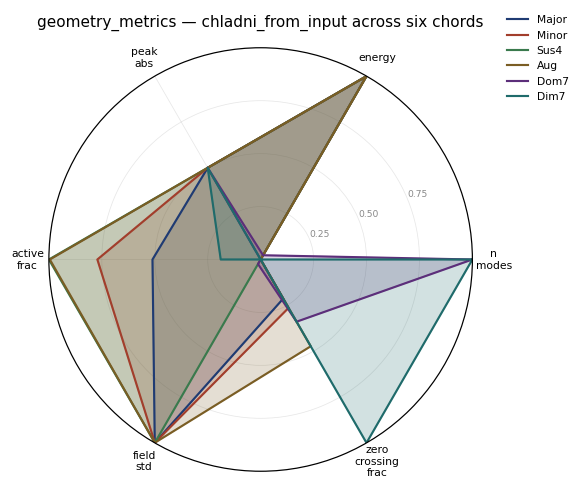

In [2]:
from biotuner.harmonic_geometry import chladni_from_input, geometry_metrics

chords = {
    "Major": HarmonicInput(ratios=[Fraction(1), Fraction(5, 4), Fraction(3, 2)]),
    "Minor": HarmonicInput(ratios=[Fraction(1), Fraction(6, 5), Fraction(3, 2)]),
    "Sus4":  HarmonicInput(ratios=[Fraction(1), Fraction(4, 3), Fraction(3, 2)]),
    "Aug":   HarmonicInput(ratios=[Fraction(1), Fraction(5, 4), Fraction(8, 5)]),
    "Dom7":  HarmonicInput(ratios=[Fraction(1), Fraction(5, 4),
                                    Fraction(3, 2), Fraction(7, 4)]),
    "Dim7":  HarmonicInput(ratios=[Fraction(1), Fraction(6, 5),
                                    Fraction(7, 5), Fraction(12, 7)]),
}
rows = [
    geometry_metrics(chladni_from_input(
        inp, plate="rectangular", plate_kwargs={"resolution": 129},
    ))
    for inp in chords.values()
]
fig, _ = plotting.plot_metric_radar(
    rows, labels=list(chords.keys()),
    metrics=["n_modes", "energy", "peak_abs",
             "active_frac", "field_std", "zero_crossing_frac"],
    title="geometry_metrics — chladni_from_input across six chords",
);


## Trajectory — recursive polygon along a chord morph

`recursive_polygon` was chosen because its scalar metrics (perimeter,
scale_factor, bump_angle, area) vary continuously with the chord — every
interpolation step changes the output. Topology-driven generators jump in
discrete steps and are less informative here.

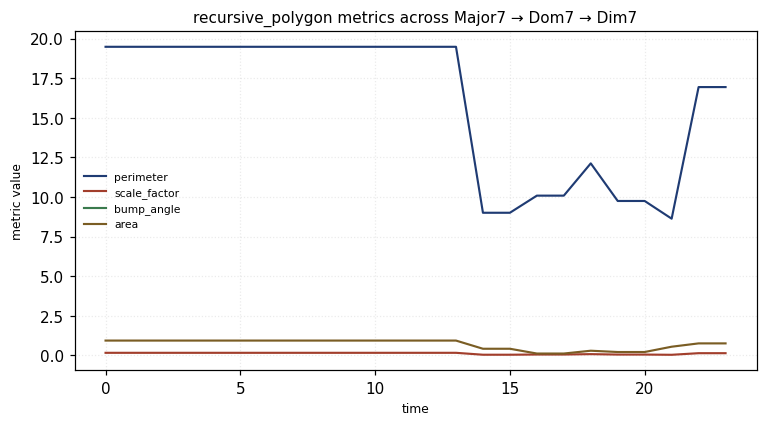

In [3]:
from biotuner.harmonic_geometry import interpolate_chords, recursive_polygon

major7 = HarmonicInput(ratios=[Fraction(1), Fraction(5, 4),
                                Fraction(3, 2), Fraction(15, 8)])
dom7   = HarmonicInput(ratios=[Fraction(1), Fraction(5, 4),
                                Fraction(3, 2), Fraction(7, 4)])
dim7   = HarmonicInput(ratios=[Fraction(1), Fraction(6, 5),
                                Fraction(7, 5), Fraction(12, 7)])
def morph(a, b, n):
    return [interpolate_chords(a, b, i/(n-1)) for i in range(n)]

frames = morph(major7, dom7, 12) + morph(dom7, dim7, 12)
metrics_per_frame = [geometry_metrics(recursive_polygon(f, depth=3))
                     for f in frames]

# plot_metric_trajectory expects a dict {name: array(T)} — transpose the
# per-frame list of dicts to the column-oriented layout it wants.
keys_to_plot = ["perimeter", "scale_factor", "bump_angle", "area"]
metric_arrays = {
    k: np.array([m.get(k, np.nan) for m in metrics_per_frame], dtype=float)
    for k in keys_to_plot
}

fig, _ = plotting.plot_metric_trajectory(
    metric_arrays,
    metrics=keys_to_plot,
    title="recursive_polygon metrics across Major7 → Dom7 → Dim7",
);


## `interpolate_chords` — visualising the morph

Sampling the morph at fixed `t` and rendering with `recursive_polygon`
gives a visual preview of what the animation does between two chords.

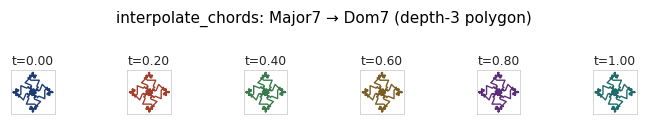

In [4]:
ts     = np.linspace(0.0, 1.0, 6)
frames = [interpolate_chords(major7, dom7, float(t)) for t in ts]
geoms  = [recursive_polygon(f, depth=3) for f in frames]
plotting.gallery(geoms, titles=[f"t={t:.2f}" for t in ts], n_cols=6,
                 suptitle="interpolate_chords: Major7 → Dom7 (depth-3 polygon)");


## `fade_in_components` — growing a chord by extension

Useful for animations that build up a chord one component at a time —
ramp `t` from 0 to 1 and the extra components appear without disturbing
the ratio of the existing ones.

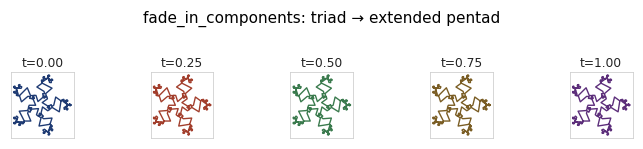

In [5]:
from biotuner.harmonic_geometry import fade_in_components

base = HarmonicInput(ratios=[Fraction(1), Fraction(5, 4), Fraction(3, 2)],
                     amplitudes=[1.0, 0.8, 0.7])
ext  = HarmonicInput(ratios=[Fraction(1), Fraction(5, 4), Fraction(3, 2),
                              Fraction(7, 4), Fraction(15, 8)],
                     amplitudes=[1.0, 0.8, 0.7, 0.6, 0.5])
ts     = np.linspace(0.0, 1.0, 5)
frames = [fade_in_components(base, ext, float(t)) for t in ts]
geoms  = [recursive_polygon(f, depth=3) for f in frames]
plotting.gallery(geoms, titles=[f"t={t:.2f}" for t in ts], n_cols=5,
                 suptitle="fade_in_components: triad → extended pentad");


## `blend_fields` — pixel-space crossfade between two algorithms

Used in the reel to morph between two paradigms on a shared grid — for
instance a Chladni plate fading into a quasicrystal field. The two
geometries must share `field_grid` shape.

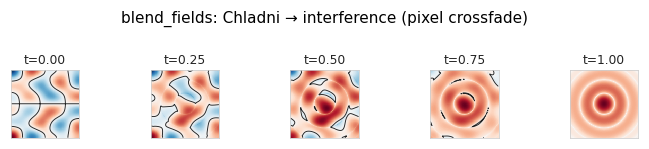

In [6]:
from biotuner.harmonic_geometry import (
    blend_fields, chladni_field_rectangular,
    harmonic_interference_field_2d,
)
a = chladni_field_rectangular([(2, 3), (3, 5), (4, 1)], resolution=129)
b = harmonic_interference_field_2d(
    HarmonicInput(ratios=[Fraction(1), Fraction(5, 4), Fraction(3, 2)]),
    resolution=129, extent=1.0,
)
ts     = np.linspace(0.0, 1.0, 5)
frames = [blend_fields(a, b, float(t), require_same_grid=False) for t in ts]
plotting.gallery(frames, titles=[f"t={t:.2f}" for t in ts], n_cols=5,
                 suptitle="blend_fields: Chladni → interference (pixel crossfade)");
